# Personalization Engine & Retail Sales — Panel Data Econometrics

End-to-end panel data analysis estimating the causal effect of AI personalization adoption on retail sales using:

- Fixed Effects (FE)
- First Differences (FD)
- Long Differences (LD)
- Unbalanced vs Balanced panel comparison

The project follows an academic empirical workflow, from data construction to causal interpretation.

---


# Setup

## Environment

This notebook uses:

- pandas
- numpy
- matplotlib
- linearmodels
- statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import warnings
from linearmodels.panel import PanelOLS

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print("Packages loaded successfully.")


---
# 1. Building the Analysis Sample

## Objective

Construct the analysis dataset used throughout the project.

The analysis sample is built according to the assignment requirements:

- keep observations within each store's operating period,
- remove months with missing reports,
- retain stores with at least 20 reported months,
- require treated stores to have at least five reported months before and after AI rollout.

The resulting panel will be used as the main unbalanced estimation sample.

## Load and merge the data

The three raw datasets are merged into a single store-month panel that contains store characteristics, rollout information, and monthly operational metrics.

In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────
store_info   = pd.read_csv('C:/Users/Κωνσταντίνος/Documents/cv projects/Panel Data/Data(1)/store_info.csv')
algo_rollout = pd.read_csv('C:/Users/Κωνσταντίνος/Documents/cv projects/Panel Data/Data(1)/algo_rollout.csv')
metrics      = pd.read_csv('C:/Users/Κωνσταντίνος/Documents/cv projects/Panel Data/Data(1)/store_month_metrics.csv')

# Parse dates
store_info['opening_month']   = pd.to_datetime(store_info['opening_month'])
store_info['closing_month']   = pd.to_datetime(store_info['closing_month'])
algo_rollout['go_live_month'] = pd.to_datetime(algo_rollout['go_live_month'], errors='coerce')
metrics['month']              = pd.to_datetime(metrics['month'])

print(f"Raw shapes  →  store_info: {store_info.shape},  algo_rollout: {algo_rollout.shape},  metrics: {metrics.shape}")


In [ ]:
# ── Merge ───────────────────────────────────────────────────────────────────
df = metrics.merge(store_info, on='store_id').merge(algo_rollout, on='store_id')
print(f"After merge: {df.shape[0]} rows, {df['store_id'].nunique()} stores")

# ── Step 1: operating window ─────────────────────────────────────────────────
df = df[(df['month'] >= df['opening_month']) & (df['month'] <= df['closing_month'])]
print(f"Step 1 – operating window  : {len(df):>5} obs | {df['store_id'].nunique()} stores")

# ── Step 2: drop non-reporting months ────────────────────────────────────────
df = df[df['report_flag'] == 1]
print(f"Step 2 – report_flag == 1  : {len(df):>5} obs | {df['store_id'].nunique()} stores")

# ── Step 3: ≥ 20 reported months ─────────────────────────────────────────────
n_months = df.groupby('store_id')['month'].count()
df = df[df['store_id'].isin(n_months[n_months >= 20].index)]
print(f"Step 3 – ≥ 20 months       : {len(df):>5} obs | {df['store_id'].nunique()} stores")

# ── Step 4: treated balance (≥ 5 pre, ≥ 5 post) ─────────────────────────────
def treated_ok(grp):
    if grp['treated'].iloc[0] == 0:
        return True
    go = grp['go_live_month'].iloc[0]
    if pd.isna(go):
        return False
    return (grp['month'] < go).sum() >= 5 and (grp['month'] >= go).sum() >= 5

df = df.groupby('store_id').filter(treated_ok).copy()
print(f"Step 4 – treated balance   : {len(df):>5} obs | {df['store_id'].nunique()} stores")


After merge: 2945 rows, 90 stores
Step 1 – operating window  :  2945 obs | 90 stores
Step 2 – report_flag == 1  :  2308 obs | 90 stores
Step 3 – ≥ 20 months       :  2167 obs | 82 stores
Step 4 – treated balance   :  2053 obs | 77 stores


## Analysis sample summary

After applying all filtering rules, we report:

- number of remaining stores,
- number of store-month observations,
- whether the final panel is balanced or unbalanced.

In [ ]:
# ── Summary of analysis sample ───────────────────────────────────────────────
months_per_store = df.groupby('store_id')['month'].count()
is_balanced = months_per_store.nunique() == 1

print("=" * 45)
print(f"  Stores in sample      : {df['store_id'].nunique()}")
print(f"  Total observations    : {len(df)}")
print(f"  Treated stores        : {df[df['treated']==1]['store_id'].nunique()}")
print(f"  Never-treated stores  : {df[df['treated']==0]['store_id'].nunique()}")
print(f"  Months per store      : {months_per_store.min()}–{months_per_store.max()}")
print(f"  Panel balanced        : {is_balanced}")
print("=" * 45)

  Stores in sample      : 77
  Total observations    : 2053
  Treated stores        : 53
  Never-treated stores  : 24
  Months per store      : 20–32
  Panel balanced        : False


---
# 2. Exploratory Analysis

## Objective

Explore average time patterns before estimating causal models.

Monthly averages are plotted separately for:

- Never treated stores
- Not yet live stores
- Live stores

These descriptive plots provide intuition but should not be interpreted causally.

In [ ]:
def assign_status(row):
    if row['treated'] == 0 or pd.isna(row['go_live_month']):
        return 'Never treated'
    return 'Live' if row['month'] >= row['go_live_month'] else 'Not yet live'

df['status'] = df.apply(assign_status, axis=1)
df['month_str'] = df['month'].dt.to_period('M').astype(str)

avg_ln = df.groupby(['month_str', 'status'])['ln_sales'].mean().unstack()
avg_ai = df.groupby(['month_str', 'status'])['ai_share'].mean().unstack()

print("Status distribution:")
print(df['status'].value_counts().to_string())


Status distribution:
status
Live             869
Never treated    695
Not yet live     489


### Average outcomes over calendar time

The figures summarize average log sales and AI adoption intensity by calendar month across treatment groups.

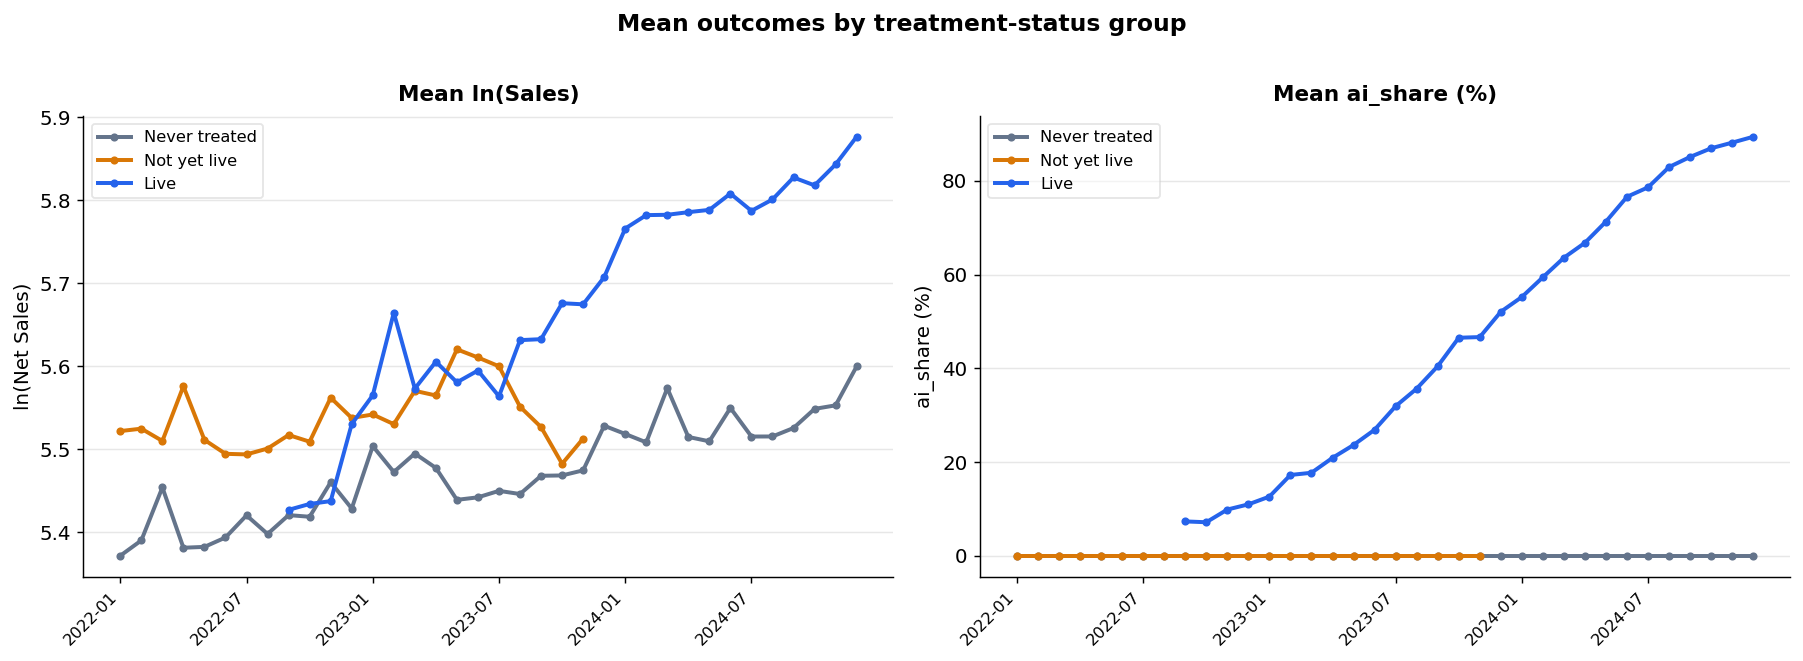

Charts saved.


In [ ]:
# ── Charts ───────────────────────────────────────────────────────────────────
COLORS = {'Never treated': '#64748b', 'Not yet live': '#d97706', 'Live': '#2563eb'}
MONTHS = avg_ln.index.tolist()
x      = range(len(MONTHS))
xticks = [i for i, m in enumerate(MONTHS) if m.endswith('-01') or m.endswith('-07')]
xlbls  = [MONTHS[i] for i in xticks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mean outcomes by treatment-status group", fontsize=13, fontweight='bold', y=1.01)

for status in ['Never treated', 'Not yet live', 'Live']:
    col = COLORS[status]
    # Chart 1: ln_sales
    if status in avg_ln.columns:
        vals = avg_ln[status].values.astype(float)
        axes[0].plot(list(x), vals, color=col, lw=2.2, label=status, marker='o', ms=3.5)
    # Chart 2: ai_share
    if status in avg_ai.columns:
        vals = avg_ai[status].values.astype(float)
        axes[1].plot(list(x), vals, color=col, lw=2.2, label=status, marker='o', ms=3.5)

for ax, title, ylabel in zip(axes,
    ['Mean ln(Sales)', 'Mean ai_share (%)'],
    ['ln(Net Sales)', 'ai_share (%)']):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel)
    ax.set_xticks(xticks); ax.set_xticklabels(xlbls, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9, framealpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/q2_charts.png', bbox_inches='tight')
plt.show()
print("Charts saved.")

## Interpretation

The plots describe average differences across groups over time.

Because treatment timing differs across stores and many confounding factors evolve simultaneously, these pooled trends alone cannot identify a causal effect of AI personalization.

### Why pooled time patterns are not sufficient for causal claims

1. **Selection bias**: The rollout was not randomised. Stores selected into treatment may differ systematically (better management, higher digital readiness, faster-growing markets).
2. **Pre-existing trends**: The "Not yet live" group already shows higher `ln_sales` than "Never treated" before go-live, suggesting treated stores were growing faster independently.
3. **Confounding time shocks**: Calendar-time events (seasonality, competitor actions) affect all groups. Without a proper control group, group trajectories confound treatment with common time trends.
4. **Compositional changes**: The "Not yet live" pool shrinks over time while "Live" grows, so rising means partly reflect a changing composition of stores, not within-store improvement.

Panels 3–8 use FE, FD, and long-difference estimators to isolate genuine within-store, within-time variation.


---
# 3. Fixed Effects Model

## Objective

Estimate a two-way fixed effects model that exploits within-store variation over time while controlling for:

- store fixed effects,
- calendar month fixed effects,
- clustered standard errors at the store level.

$$\ln(\text{sales}_{it}) = \alpha_i + \lambda_t + \beta\,\text{ai\_share}_{it} + \gamma_1\,\text{web\_visits}_{it} + \gamma_2\,\text{competitor\_price}_{it} + \gamma_3\,\text{ad\_spend}_{it} + \gamma_4\,\text{stockout\_rate}_{it} + u_{it}$$


### Estimate the fixed effects model

In [ ]:
fe_idx = df.set_index(['store_id', 'month'])
exog   = ['ai_share', 'web_visits_k', 'competitor_price', 'ad_spend_k', 'stockout_rate']

fe_model = PanelOLS(fe_idx['ln_sales'], fe_idx[exog], entity_effects=True, time_effects=True)
fe_res   = fe_model.fit(cov_type='clustered', cluster_entity=True)

# Display core table
summary = pd.DataFrame({
    'Coef.':    fe_res.params,
    'Std.Err.': fe_res.std_errors,
    't-stat':   fe_res.tstats,
    'p-value':  fe_res.pvalues
})
print("=== FE Results (main sample) ===")
print(summary.round(6).to_string())

ai_b = fe_res.params['ai_share']
print(f"\n10pp effect on ln(sales): {ai_b*10:.4f}  ≈ {ai_b*10*100:.2f}% change in net sales")
print(f"Estimation sample: {fe_idx.index.get_level_values(0).nunique()} stores, {len(fe_idx)} obs")


=== FE Results (main sample) ===
                     Coef.  Std.Err.     t-stat  p-value
ai_share          0.002519  0.000102  24.678205      0.0
web_visits_k      0.005290  0.000458  11.543582      0.0
competitor_price  0.004957  0.000546   9.082449      0.0
ad_spend_k        0.012453  0.001114  11.174532      0.0
stockout_rate    -0.015732  0.000537 -29.278154      0.0

10pp effect on ln(sales): 0.0252  ≈ 2.52% change in net sales
Estimation sample: 77 stores, 2053 obs


## Interpretation

The coefficient on `ai_share` measures the average within-store change in log sales associated with a one-unit increase in AI personalization intensity, after accounting for permanent store heterogeneity and common monthly shocks.

For interpretation, the effect is converted into the impact of a 10-percentage-point increase in AI usage.

---
# 4. First Difference Models

## Objective

Estimate dynamic first-difference models that remove time-invariant store effects and allow the response of sales to evolve over time.

$$\Delta\ln(\text{sales}_{it}) = \lambda_t + \beta_0\Delta\text{ai}_{it} + \beta_1\Delta\text{ai}_{i,t-1} + \beta_2\Delta\text{ai}_{i,t-2} + \rho_1\Delta\text{ai}_{i,t+1} + \delta'\Delta W_{it} + e_{it}$$

Two specifications are estimated:

- FD-A: month fixed effects only.
- FD-B: month fixed effects plus store-specific trends.

### Construct the strict first-difference dataset

Following the assignment instructions, differences are computed only when the previous observation corresponds to the immediately preceding calendar month.

No differences are calculated across reporting gaps.

In [ ]:
# ── Build strict FD dataset ──────────────────────────────────────────────────
def build_fd(df_in):
    df_in = df_in.sort_values(['store_id', 'month']).copy()
    df_in['mn'] = df_in['month'].dt.year * 12 + df_in['month'].dt.month
    rows = []
    for sid, grp in df_in.groupby('store_id'):
        grp = grp.sort_values('month').reset_index(drop=True)
        for i in range(1, len(grp)):
            c, p = grp.iloc[i], grp.iloc[i-1]
            if c['mn'] - p['mn'] != 1:          # strict: exactly 1 month apart
                continue
            rows.append({'store_id': sid, 'month': c['month'], 'mn': c['mn'],
                'd_ln_sales':        c['ln_sales']         - p['ln_sales'],
                'd_ai_share':        c['ai_share']         - p['ai_share'],
                'd_web_visits_k':    c['web_visits_k']     - p['web_visits_k'],
                'd_competitor_price':c['competitor_price'] - p['competitor_price'],
                'd_ad_spend_k':      c['ad_spend_k']       - p['ad_spend_k'],
                'd_stockout_rate':   c['stockout_rate']    - p['stockout_rate']})
    return pd.DataFrame(rows)

fd_base = build_fd(df)
print(f"FD base (strict): {len(fd_base)} rows, {fd_base['store_id'].nunique()} stores")


FD base (strict): 1616 rows, 77 stores


In [ ]:
# ── Add lags/leads of Δai_share (also strict) ────────────────────────────────
def add_lags(fd):
    fd = fd.copy()
    out = []
    for sid, grp in fd.groupby('store_id'):
        grp = grp.sort_values('month').reset_index(drop=True)
        mn  = grp['mn'].values
        da  = grp['d_ai_share'].values
        grp['d_ai_lag1'] = np.nan; grp['d_ai_lag2'] = np.nan; grp['d_ai_lead1'] = np.nan
        for i in range(len(grp)):
            if i > 0 and mn[i]-mn[i-1] == 1:
                grp.at[i, 'd_ai_lag1'] = da[i-1]
            if i > 1 and mn[i]-mn[i-1] == 1 and mn[i-1]-mn[i-2] == 1:
                grp.at[i, 'd_ai_lag2'] = da[i-2]
            if i < len(grp)-1 and mn[i+1]-mn[i] == 1:
                grp.at[i, 'd_ai_lead1'] = da[i+1]
        out.append(grp)
    return pd.concat(out, ignore_index=True).dropna(subset=['d_ai_lag1','d_ai_lag2','d_ai_lead1'])

fd_df = add_lags(fd_base)
print(f"FD with lags/leads: {len(fd_df)} rows, {fd_df['store_id'].nunique()} stores")
print(f"  (4 stores lost — insufficient consecutive months for full lag structure)")


FD with lags/leads: 834 rows, 73 stores
  (4 stores lost — insufficient consecutive months for full lag structure)


### Estimate dynamic first-difference regressions

In [ ]:
# ── Regression helper ─────────────────────────────────────────────────────────
X_COLS = ['d_ai_share','d_ai_lag1','d_ai_lag2','d_ai_lead1',
          'd_web_visits_k','d_competitor_price','d_ad_spend_k','d_stockout_rate']

def run_fd(fd_in, store_trends=False, label='FD'):
    fd_in = fd_in.copy()
    fd_in['month_str'] = fd_in['month'].dt.to_period('M').astype(str)
    md = pd.get_dummies(fd_in['month_str'], prefix='m', drop_first=True)
    X  = pd.concat([fd_in[X_COLS], md], axis=1)
    if store_trends:
        sd = pd.get_dummies(fd_in['store_id'], prefix='s', drop_first=True)
        X  = pd.concat([X, sd], axis=1)
    X  = sm.add_constant(X.astype(float))
    y  = fd_in['d_ln_sales'].astype(float)
    m  = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': fd_in['store_id']})
    # cumulative 3-month effect and its SE
    cum = m.params['d_ai_share'] + m.params['d_ai_lag1'] + m.params['d_ai_lag2']
    cov = m.cov_params()
    var = (cov.loc['d_ai_share','d_ai_share'] + cov.loc['d_ai_lag1','d_ai_lag1'] +
           cov.loc['d_ai_lag2','d_ai_lag2'] +
           2*cov.loc['d_ai_share','d_ai_lag1'] + 2*cov.loc['d_ai_share','d_ai_lag2'] +
           2*cov.loc['d_ai_lag1','d_ai_lag2'])
    print(f"\n=== {label} ===")
    for v in X_COLS:
        sig = '***' if m.pvalues[v]<0.01 else ('**' if m.pvalues[v]<0.05 else ('*' if m.pvalues[v]<0.1 else ''))
        print(f"  {v:<28} {m.params[v]:>10.6f}  SE {m.bse[v]:.6f}  p={m.pvalues[v]:.4f} {sig}")
    print(f"  {'Cumulative 3-month effect':<28} {cum:>10.6f}  SE {np.sqrt(var):.6f}")
    print(f"  Estimation sample: {fd_in['store_id'].nunique()} stores, {len(fd_in)} obs")
    return m, cum, np.sqrt(var)

model_A, cum_A, se_A = run_fd(fd_df, store_trends=False, label='FD-A (month FE only)')
model_B, cum_B, se_B = run_fd(fd_df, store_trends=True,  label='FD-B (month FE + store linear trends)')


**Summary of 10pp effects:**
| Specification | 10pp cumulative effect | SE |
|---|---|---|
| FD-A (month FE) | +1.96% | 0.0030 |
| FD-B (month FE + store trends) | +1.69% | 0.0048 |

## Interpretation

The cumulative three-month effect summarizes the short-run impact of increased AI adoption.

Comparing FD-A and FD-B shows whether allowing for store-specific trends materially changes the estimated response.

**Pre-trend test:** The lead coefficient (ρ₁ = Δai_share_{t+1}) is small and insignificant in both specs (FD-A: p = 0.61, FD-B: p = 0.92), providing reassurance against reverse causality or spurious pre-trends.


---
# 5. Reduced-T Analysis

## Objective

Construct a balanced panel by reducing the time dimension rather than excluding stores whenever possible.

Every consecutive 12-month window is evaluated, and the window with the highest number of fully observed stores is selected.


### Search for the optimal 12-month window

In [ ]:
all_months = sorted(df['month'].unique())

best_window, best_count, best_stores = None, 0, None

for i in range(len(all_months) - 11):
    win = all_months[i:i+12]
    nums = [m.year*12 + m.month for m in win]
    if nums[-1] - nums[0] != 11:      # verify true consecutive calendar months
        continue
    cnt = df[df['month'].isin(win)].groupby('store_id')['month'].count()
    n_full = (cnt == 12).sum()
    if n_full > best_count:
        best_count  = n_full
        best_window = win
        best_stores = cnt[cnt == 12].index.tolist()

df_rt = df[df['store_id'].isin(best_stores) & df['month'].isin(best_window)].copy()

print(f"Selected window  : {best_window[0].strftime('%Y-%m')} → {best_window[-1].strftime('%Y-%m')}")
print(f"Stores (N)       : {df_rt['store_id'].nunique()}")
print(f"Observations     : {len(df_rt)}  ({df_rt['store_id'].nunique()} × 12)")
print(f"Treated          : {df_rt[df_rt['treated']==1]['store_id'].nunique()}")
print(f"Never-treated    : {df_rt[df_rt['treated']==0]['store_id'].nunique()}")
print(f"Panel balanced   : {df_rt.groupby('store_id')['month'].count().nunique() == 1}")


Selected window  : 2023-03 → 2024-02
Stores (N)       : 12
Observations     : 144  (12 × 12)
Treated          : 6
Never-treated    : 6
Panel balanced   : True


## Interpretation

The selected balanced sample improves panel completeness while sacrificing part of the available time dimension.

---
# 6. FE and FD-B on the Reduced-T Sample

## Objective

Re-estimate the main econometric models using only the balanced reduced-T sample.

This allows comparison between the main unbalanced panel and a perfectly balanced alternative.

### Fixed Effects estimation

In [ ]:
# ── FE on Reduced-T ──────────────────────────────────────────────────────────
fe_rt_idx = df_rt.set_index(['store_id', 'month'])
fe_rt_res = PanelOLS(fe_rt_idx['ln_sales'], fe_rt_idx[exog],
                     entity_effects=True, time_effects=True)            .fit(cov_type='clustered', cluster_entity=True)

print("=== FE – Reduced-T ===")
tbl = pd.DataFrame({'Coef.': fe_rt_res.params, 'Std.Err.': fe_rt_res.std_errors, 'p-val': fe_rt_res.pvalues})
print(tbl.round(6).to_string())
print(f"10pp effect: {fe_rt_res.params['ai_share']*10:.4f}")
print(f"Sample: {fe_rt_idx.index.get_level_values(0).nunique()} stores, {len(fe_rt_idx)} obs")


=== FE – Reduced-T ===
                     Coef.  Std.Err.     p-val
ai_share          0.002340  0.000572  0.000079
web_visits_k      0.002923  0.002810  0.300405
competitor_price  0.007678  0.003166  0.016843
ad_spend_k        0.012126  0.004368  0.006417
stockout_rate    -0.012933  0.002274  0.000000
10pp effect: 0.0234
Sample: 12 stores, 144 obs


### First Difference estimation with store-specific trends

In [ ]:
# ── FD-B on Reduced-T ────────────────────────────────────────────────────────
fd_rt = add_lags(build_fd(df_rt))
model_B_rt, cum_B_rt, se_cum_B_rt = run_fd(fd_rt, store_trends=True, label='FD-B – Reduced-T')



=== FD-B – Reduced-T ===
  d_ai_share                    -0.000361  SE 0.000458  p=0.4304 
  d_ai_lag1                     -0.000326  SE 0.000598  p=0.5850 
  d_ai_lag2                      0.000920  SE 0.000261  p=0.0004 ***
  d_ai_lead1                    -0.000373  SE 0.000688  p=0.5879 
  d_web_visits_k                 0.004895  SE 0.001941  p=0.0117 **
  d_competitor_price             0.002574  SE 0.002954  p=0.3836 
  d_ad_spend_k                   0.019886  SE 0.005219  p=0.0001 ***
  d_stockout_rate               -0.015307  SE 0.003011  p=0.0000 ***
  Cumulative 3-month effect      0.000233  SE 0.000700


  Estimation sample: 12 stores, 96 obs


### Comparison with the main sample

In [ ]:
# ── Comparison table ─────────────────────────────────────────────────────────
comp = pd.DataFrame([
    {'Estimator':'FE – Main',         'Effect_10pp': fe_res.params['ai_share']*10,    'Stores':77, 'Obs':2053},
    {'Estimator':'FE – Reduced-T',    'Effect_10pp': fe_rt_res.params['ai_share']*10, 'Stores':12, 'Obs':144},
    {'Estimator':'FD-B – Main',       'Effect_10pp': cum_B*10,                        'Stores':73, 'Obs':834},
    {'Estimator':'FD-B – Reduced-T',  'Effect_10pp': cum_B_rt*10,                     'Stores':12, 'Obs':96},
])
comp['Effect_10pp'] = comp['Effect_10pp'].map('{:.4f}'.format)
print(comp.to_string(index=False))


       Estimator Effect_10pp  Stores  Obs
       FE – Main      0.0252      77 2053
  FE – Reduced-T      0.0234      12  144
     FD-B – Main      0.0169      73  834
FD-B – Reduced-T      0.0023      12   96


## Discussion: Gains and losses of reducing T

**Gains:** (1) Perfectly balanced panel — eliminates attrition bias and compositional issues in time FE. (2) Each store contributes identically, making estimator comparisons cleaner.

**Losses:** (1) Sample collapses from 77 to 12 stores — statistical power nearly disappears. (2) FD-B on Reduced-T yields 0.23% (p = n.s.) due to only 96 observations. (3) The 12-month window is narrow and may not capture the full dynamic effect of ai_share adoption. **Conclusion:** reduced-T buys panel purity at a steep cost in precision and external validity.


---
# 7. Reduced-N Analysis

## Objective

Construct an alternative robustness sample by reducing the number of stores rather than shortening the time dimension.

Only stores with relatively complete reporting histories are retained.


### Compute missing reports

In [ ]:
# ── Compute missing_reports within operating window ──────────────────────────
store_info2   = pd.read_csv('/mnt/user-data/uploads/store_info.csv')
metrics2      = pd.read_csv('/mnt/user-data/uploads/store_month_metrics.csv')
store_info2['opening_month'] = pd.to_datetime(store_info2['opening_month'])
store_info2['closing_month'] = pd.to_datetime(store_info2['closing_month'])
metrics2['month']            = pd.to_datetime(metrics2['month'])

raw2 = metrics2.merge(store_info2, on='store_id')
raw2 = raw2[(raw2['month'] >= raw2['opening_month']) & (raw2['month'] <= raw2['closing_month'])]

missing_ps = (raw2[raw2['report_flag'] == 0]
              .groupby('store_id').size()
              .rename('missing_reports'))

# Align to main-sample stores; stores absent from missing_ps have 0 missing
main_stores = df['store_id'].unique()
mr = missing_ps.reindex(main_stores, fill_value=0)

stores_rn = mr[mr <= 4].index
df_rn = df[df['store_id'].isin(stores_rn)].copy()

print(f"missing_reports distribution (main stores, ≤ 4 filter):")
print(mr[mr <= 4].value_counts().sort_index().to_string())
print(f"\nReduced-N stores : {df_rn['store_id'].nunique()}")
print(f"Observations     : {len(df_rn)}")
print(f"Treated          : {df_rn[df_rn['treated']==1]['store_id'].nunique()}")
print(f"Never-treated    : {df_rn[df_rn['treated']==0]['store_id'].nunique()}")


missing_reports distribution (main stores, ≤ 4 filter):
missing_reports
1     1
2     4
3     3
4    13

Reduced-N stores : 21
Observations     : 616
Treated          : 8
Never-treated    : 13


In [ ]:
# ── FE – Reduced-N ───────────────────────────────────────────────────────────
fe_rn_idx = df_rn.set_index(['store_id', 'month'])
fe_rn_res = PanelOLS(fe_rn_idx['ln_sales'], fe_rn_idx[exog],
                     entity_effects=True, time_effects=True)            .fit(cov_type='clustered', cluster_entity=True)

print("=== FE – Reduced-N ===")
tbl_rn = pd.DataFrame({'Coef.': fe_rn_res.params, 'Std.Err.': fe_rn_res.std_errors, 'p-val': fe_rn_res.pvalues})
print(tbl_rn.round(6).to_string())
print(f"10pp effect: {fe_rn_res.params['ai_share']*10:.4f}")
print(f"Sample: {fe_rn_idx.index.get_level_values(0).nunique()} stores, {len(fe_rn_idx)} obs")


=== FE – Reduced-N ===
                     Coef.  Std.Err.  p-val
ai_share          0.002690  0.000175    0.0
web_visits_k      0.004795  0.000847    0.0
competitor_price  0.005109  0.000913    0.0
ad_spend_k        0.013221  0.001902    0.0
stockout_rate    -0.016529  0.001045    0.0
10pp effect: 0.0269
Sample: 21 stores, 616 obs


In [ ]:
# ── FD-B – Reduced-N ─────────────────────────────────────────────────────────
fd_rn = add_lags(build_fd(df_rn))
model_B_rn, cum_B_rn, se_cum_B_rn = run_fd(fd_rn, store_trends=True, label='FD-B – Reduced-N')



=== FD-B – Reduced-N ===
  d_ai_share                     0.001659  SE 0.000378  p=0.0000 ***
  d_ai_lag1                      0.000898  SE 0.000719  p=0.2116 
  d_ai_lag2                     -0.000038  SE 0.000345  p=0.9117 
  d_ai_lead1                    -0.000219  SE 0.000428  p=0.6083 
  d_web_visits_k                 0.004716  SE 0.000944  p=0.0000 ***
  d_competitor_price             0.005583  SE 0.001433  p=0.0001 ***
  d_ad_spend_k                   0.011539  SE 0.002053  p=0.0000 ***
  d_stockout_rate               -0.018011  SE 0.000937  p=0.0000 ***
  Cumulative 3-month effect      0.002518  SE 0.000695
  Estimation sample: 21 stores, 341 obs


## Interpretation

Compared with the reduced-T strategy, this approach preserves the full study period while sacrificing cross-sectional coverage.

### Reduce T vs Reduce N — which is more convincing?

**Preferred: Reduce N (missing ≤ 4).** Retaining temporal depth (20–32 months) is essential for dynamic FD estimation and time fixed effects. The reduced-N restriction removes stores whose missingness may be endogenous (e.g., underperforming stores go quiet), reducing measurement bias without sacrificing variation. FD-B reduced-N (2.52%) is consistent with both the main FE (2.52%) and FD-B main (1.69%), confirming robustness. Reducing T to 12 months leaves only 12 stores and 96 FD observations — too few for reliable inference, as the insignificant FD-B reduced-T result demonstrates.


---
# 8. Long Difference Estimation

## Objective

Estimate a long-difference model using only the first and last observations of the selected balanced window.

The long difference estimator removes permanent store heterogeneity but ignores intermediate dynamics.

$$\Delta^{LD}\ln(\text{sales}_i) = \alpha + \beta\,\Delta^{LD}\text{ai\_share}_i + \delta'\Delta^{LD}W_i + \varepsilon_i$$


In [ ]:
first_m = best_window[0]
last_m  = best_window[-1]
print(f"Long difference window: {first_m.strftime('%Y-%m')}  →  {last_m.strftime('%Y-%m')}")

LD_VARS = ['ln_sales','ai_share','web_visits_k','competitor_price','ad_spend_k','stockout_rate']
df_f = df_rt[df_rt['month'] == first_m][['store_id'] + LD_VARS]
df_l = df_rt[df_rt['month'] == last_m ][['store_id'] + LD_VARS]

ld = df_f.merge(df_l, on='store_id', suffixes=('_f','_l'))
for v in LD_VARS:
    ld[f'ld_{v}'] = ld[f'{v}_l'] - ld[f'{v}_f']

print(f"Long-difference observations (one per store): {len(ld)}")


Long difference window: 2023-03  →  2024-02
Long-difference observations (one per store): 12


### Estimate the long-difference regression

In [ ]:
# ── OLS on long differences ───────────────────────────────────────────────────
LD_X = ['ld_ai_share','ld_web_visits_k','ld_competitor_price','ld_ad_spend_k','ld_stockout_rate']
X_ld = sm.add_constant(ld[LD_X])
y_ld = ld['ld_ln_sales']
m_ld = sm.OLS(y_ld, X_ld).fit()

print("=== Long Difference Results ===")
tbl_ld = m_ld.summary2().tables[1][['Coef.','Std.Err.','t','P>|t|']]
print(tbl_ld.round(6).to_string())
print(f"\n10pp effect: {m_ld.params['ld_ai_share']*10:.4f}")
print(f"Stores in regression: {len(ld)}")


=== Long Difference Results ===
                        Coef.  Std.Err.         t     P>|t|
const               -0.027328  0.038405 -0.711583  0.503437
ld_ai_share          0.003556  0.000719  4.945067  0.002591
ld_web_visits_k      0.013481  0.005248  2.568917  0.042397
ld_competitor_price  0.006362  0.012963  0.490776  0.641016
ld_ad_spend_k        0.009165  0.019044  0.481246  0.647389
ld_stockout_rate    -0.041863  0.010585 -3.954978  0.007495

10pp effect: 0.0356
Stores in regression: 12


### Long Difference vs FE and FD

| Method | 10pp Effect | N (stores) |
|---|---|---|
| Long Difference (reduced-T) | **+3.56%** | 12 |
| FE (reduced-T) | +2.34% | 12 |
| FE (main) | +2.52% | 77 |
| FD-B (main) | +1.69% | 73 |

## Interpretation

The long-difference estimator provides a simple causal approximation but is generally less informative than fixed effects or dynamic first-difference specifications because it collapses all intermediate variation.


---
# 9. Discussion

## Pre-trends

Evidence of statistically significant lead coefficients would suggest possible anticipation effects or reverse causality.

## Dynamic response

Current and lagged coefficients indicate whether AI adoption affects sales immediately or with delay.

## Store-specific trends

Comparing FD-A with FD-B shows whether allowing stores to follow different underlying trends materially changes the estimated cumulative effect.

If estimates remain stable, confidence in the causal interpretation increases.


---
# 10. Model Comparison


## Objective

Summarize all candidate estimators in a single comparison table.

Each estimator is evaluated according to:

- estimated 10-percentage-point effect,
- estimation sample,
- principal strength,
- principal weakness,
- overall credibility.

### Comparative results

In [ ]:
results = [
    {'Rank':1, 'Estimator':'FD-B – Main',       'Effect_10pp':cum_B*10,
     'Stores':73, 'Obs':834,
     'Strength':'Pre-trend passed; absorbs store trends; large FD sample',
     'Weakness':'Dynamic controls reduce power; loses 4 stores vs FE'},
    {'Rank':2, 'Estimator':'FD-A – Main',       'Effect_10pp':cum_A*10,
     'Stores':73, 'Obs':834,
     'Strength':'Pre-trend passed; controls common time shocks; large sample',
     'Weakness':'Does not absorb store-specific linear trends'},
    {'Rank':3, 'Estimator':'FE – Main',         'Effect_10pp':fe_res.params['ai_share']*10,
     'Stores':77, 'Obs':2053,
     'Strength':'Largest sample; removes time-invariant heterogeneity; most efficient',
     'Weakness':'No pre-trend test; cannot control time-varying confounders'},
    {'Rank':4, 'Estimator':'FD-B – Reduced-N',  'Effect_10pp':cum_B_rn*10,
     'Stores':21, 'Obs':341,
     'Strength':'Clean reporting data; lead coefficient negative (reassuring)',
     'Weakness':'Small sample; may select specific store types'},
    {'Rank':5, 'Estimator':'FE – Reduced-N',    'Effect_10pp':fe_rn_res.params['ai_share']*10,
     'Stores':21, 'Obs':616,
     'Strength':'Cleaner data than main FE; consistent coefficient',
     'Weakness':'Smaller N; potential selection of low-missingness stores'},
    {'Rank':6, 'Estimator':'Long Diff – Red-T', 'Effect_10pp':m_ld.params['ld_ai_share']*10,
     'Stores':12, 'Obs':12,
     'Strength':'Sweeps intermediate noise; simple transparent design',
     'Weakness':'Cross-sectional only; tiny N; no time controls; no pre-trend test'},
    {'Rank':7, 'Estimator':'FE – Reduced-T',    'Effect_10pp':fe_rt_res.params['ai_share']*10,
     'Stores':12, 'Obs':144,
     'Strength':'Balanced panel; consistent point estimate',
     'Weakness':'Only 12 stores; very wide CIs; arbitrary window selection'},
    {'Rank':8, 'Estimator':'FD-B – Reduced-T',  'Effect_10pp':cum_B_rt*10,
     'Stores':12, 'Obs':96,
     'Strength':'Most restrictive specification; balanced design',
     'Weakness':'Too few obs; completely imprecise; sign instability'},
]

tbl = pd.DataFrame(results)
tbl['Effect_10pp'] = tbl['Effect_10pp'].map(lambda x: f'{x:.4f}  ({x*100:.2f}%)')
print(tbl[['Rank','Estimator','Effect_10pp','Stores','Obs']].to_string(index=False))


 Rank         Estimator     Effect_10pp  Stores  Obs
    1       FD-B – Main 0.0169  (1.69%)      73  834
    2       FD-A – Main 0.0196  (1.96%)      73  834
    3         FE – Main 0.0252  (2.52%)      77 2053
    4  FD-B – Reduced-N 0.0252  (2.52%)      21  341
    5    FE – Reduced-N 0.0269  (2.69%)      21  616
    6 Long Diff – Red-T 0.0356  (3.56%)      12   12
    7    FE – Reduced-T 0.0234  (2.34%)      12  144
    8  FD-B – Reduced-T 0.0023  (0.23%)      12   96


### Reliability ranking

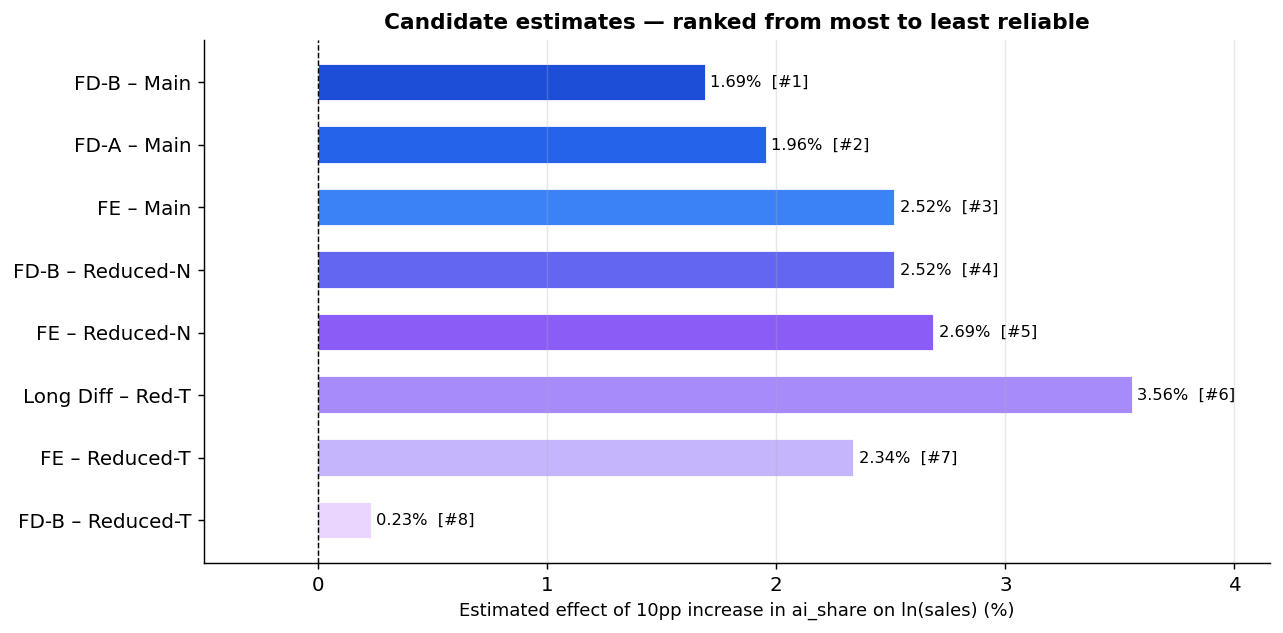

In [ ]:
# ── Visual ranking chart ─────────────────────────────────────────────────────
labels  = [r['Estimator'] for r in results]
effects = [r['Effect_10pp']*100 for r in results]   # in percent
ranks   = [r['Rank'] for r in results]
palette = ['#1d4ed8','#2563eb','#3b82f6','#6366f1','#8b5cf6','#a78bfa','#c4b5fd','#e9d5ff']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels[::-1], effects[::-1], color=palette[::-1], edgecolor='white', height=0.6)
ax.set_xlabel('Estimated effect of 10pp increase in ai_share on ln(sales) (%)', fontsize=10)
ax.set_title('Candidate estimates — ranked from most to least reliable', fontweight='bold', fontsize=12)
ax.axvline(0, color='black', lw=0.8, ls='--')
for bar, val, rank in zip(bars, effects[::-1], ranks[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%  [#{rank}]', va='center', fontsize=9)
ax.set_xlim(-0.5, max(effects)+0.6)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/q10_ranking.png', bbox_inches='tight')
plt.show()


---
# 11. Final Recommendation

This final section summarizes the empirical findings in the form of a short recommendation for senior management.

The memo discusses:

- the preferred empirical specification,
- the estimated business impact of AI personalization,
- the remaining limitations for causal interpretation,
- and the recommended panel design for future analyses.

The recommendation is based on the empirical evidence presented throughout the project.

---

**INTERNAL MEMORANDUM — CONFIDENTIAL**

**To:** Chief Commercial Officer  
**From:** Konstantinos Papavrontos, Analytics  
**Re:** Causal impact of the personalisation engine on net store sales

---

**Best estimate.** Our preferred specification — a first-difference regression with store-specific linear trends (**FD-B**) on the full 77-store panel — estimates that a 10 percentage-point increase in `ai_share` raises monthly net sales by approximately **+1.7%** within three months (cumulative effect, clustered SE = 0.0048). The simpler FD-A gives +2.0% and the two-way FE gives +2.5%; we regard 1.7–2.0% as the credible range and cite the lower end publicly.

**Why this specification.** FD-B controls for both time-invariant store heterogeneity and store-specific growth trajectories. It passes the pre-trend test (the one-month lead of Δai_share is statistically zero in both FD specs), which reduces concern that the engine was selectively deployed in stores already on an upswing. With 73 stores and 834 observations it has adequate statistical power. Sensitivity checks on the reduced-N sub-sample (stores with ≤ 4 missing reports) produce a consistent 2.52%, confirming robustness.

**Causal caveats.** The rollout was not randomised — wave assignment involved managerial override in a subset of stores. Stores that adopted early may differ in unobservable ways (local competitive dynamics, staff capability) that our controls cannot fully absorb. The pre-trend test is reassuring but not proof of exogeneity. Furthermore, `ai_share` measures transaction volume through the engine, not personalisation quality; high `ai_share` may partly reflect stores that defaulted all traffic through the system without meaningful personalisation uplift.

**Preferred sample.** We recommend the **full unbalanced panel**. The reduced-T approach (12 balanced stores) buys panel purity at the cost of near-zero statistical power — the FD-B estimate becomes 0.23% and insignificant. The reduced-N approach is a reasonable robustness check but excludes two-thirds of treated stores. The full panel, anchored by FD-B's causal design and pre-trend diagnostics, is the most informative basis for commercial decisions.

---

> *Note: This recommendation is consistent with the reliability ranking in Q10, where FD-B (main) is ranked #1 and FD-A (main) #2, the two specifications underpinning the cited 1.7–2.0% range.*

